<a href="https://colab.research.google.com/github/Redcoder815/Deep_learning_phitron/blob/main/25Midterm_Exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 👗 Smart Fashion AI with Neural Networks (Mid Term)

**Total Marks: 100 (Theory: 10 | Practical: 90)**  


---

**Instructions:**
1. Enter your course email in the cell below.
2. Read the story and problem descriptions carefully.
3. Complete the code in cells containing `# YOUR CODE HERE`. Do not modify the test cells.
4. Run all cells sequentially to ensure your tests pass before submitting.
5. Have fun!

In [ ]:
# Enter your course email here
student_email = "artificial815@gmail.com" # Example: "your.name@university.edu"

---

## 📖 Story: StyleAI — Smart Fashion Recognition

You've just joined **StyleAI**, a startup building an AI-powered wardrobe assistant app. The app lets users snap a photo of any clothing item and instantly classifies it. Your job is to build the **image classification model** that powers this feature.

The dataset is **Fashion-MNIST** — 28×28 grayscale images of 10 clothing categories:

| Label | Class Name |
|-------|------------|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |


---

## Question 1: Theory (10 Marks)

### Part A (3 Marks)
Explain the difference between **Sigmoid** and **ReLU** activation functions. Why is ReLU preferred in hidden layers of deep networks? What problem does Sigmoid cause during backpropagation in deep networks?

### Part B (4 Marks)
In the context of **Gradient Descent**:
- What is the difference between **Batch Gradient Descent**, **Stochastic Gradient Descent (SGD)**, and **Mini-batch Gradient Descent**?
- State one advantage and one disadvantage of each.
- Which type would you recommend for training on Fashion-MNIST (60,000 images), and why?

### Part C (3 Marks)
In our Fashion-MNIST problem (10 classes):
1. Why do we use `nn.CrossEntropyLoss` instead of `nn.BCELoss`?
2. Why should we **NOT** put `nn.Softmax` as the last layer when using `nn.CrossEntropyLoss`?
3. What does `loss.backward()` do?

*Double-click here to write your answers*

**Part A Answer:** Sigmoid map input value in range 0 and 1. ReLu outputs is input if it is positive. otherwise output is zero

ReLu preferred in hidden layers because it much faster in computation, reduces overfitting, allowing network to learn much faster in gradient descent.

Sigmoid cause problem during backpropagation in neural network is vanishing gradient



**Part B Answer:**
Batch gradient descent: use entire dataset to compute gradient of a single parameter update.

SGD: Use one random sample for updating parameters at each step.

Mini-batch gradient descent: Use small batch of samples per update

Advantages and disadvatages:

Batch gradient descent: Stable. but very slow

SGD: Very fast to compute. never settle exactly the minimum without learning rate decay.

Mini-batch gradient descent: Combines the stability of Batch gradeient descent and the speed of SGD. Require an extra parameter like batch size

Recommendation for fashion mnist data set is mini-batch gradient descent. Because it perfect balance into GPU memory, stabilize training noise, speed up convergence.



**Part C Answer:**

We use nn.CrossEntropyLoss for fashion mnist dataset because it built for multiclass classification. On the other hand nn.BCELoss loss for only binary class classification.

We should not put nn.softmax in the last layer when using nn.CrossEntropyLoss If add a nn.Softmax layer at the end of model, it will apply the softmax operation two times. This breaks the mathematical formulas, make incorrect loss values, and creates numerical instability during training.

loss.backward() computes the gradient descent of the loss function of learnable model parameters

---

## Question 2: Load & Explore the Data (15 Marks)

### 2.1 Download the Dataset (1 Marks)

We will use `torchvision.datasets.FashionMNIST` to download the dataset. This is similar to how we loaded data from `.npy` files in class, but here PyTorch handles the download for us.

Run the cell below to download the training and test sets:

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import numpy as np
import matplotlib.pyplot as plt

# Class names for Fashion-MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Download Fashion-MNIST — this downloads the data into a ./data folder
# download=True means it will download if not already present
full_train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True)
test_dataset_raw = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True)

train_images_all = full_train_dataset.data.numpy()  # shape: (60000, 28, 28)
train_labels_all = full_train_dataset.targets.numpy()  # shape: (60000,)
test_images_all = test_dataset_raw.data.numpy()
test_labels_all = test_dataset_raw.targets.numpy()

print(f"Training set size: {len(full_train_dataset)}")
print(f"Test set size: {len(test_dataset_raw)}")
print(f"Image shape: {full_train_dataset[0][0].size}")

Training set size: 60000
Test set size: 10000
Image shape: (28, 28)


### 2.2 Visualize Sample Images (5 Marks)

Create a **2×5 subplot figure** (figsize 12×5) showing one sample image from **each of the 10 classes**.
- Display each image in grayscale (`cmap='gray'`)
- Title each subplot with its class name
- Turn off axis ticks

*Hint: loop through classes 0-9, find one sample of each class, and plot it.*

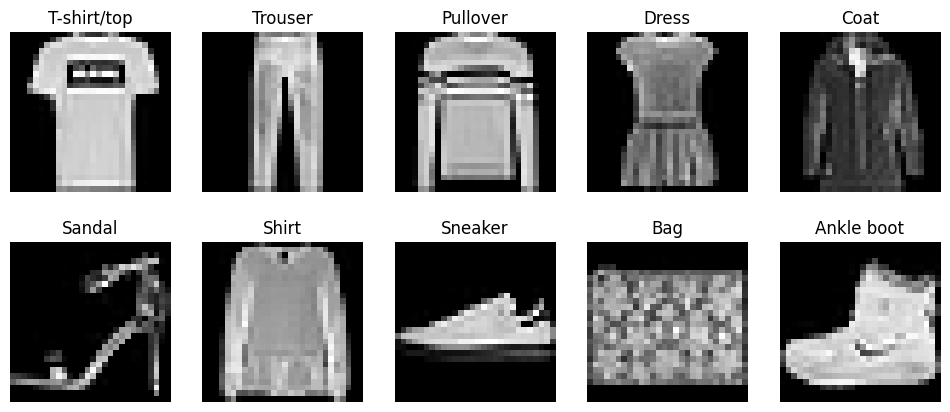

In [ ]:
# YOUR CODE HERE
fig , axes = plt.subplots(2, 5 , figsize=(12,5))
axes = axes.flatten()

for i in range(10):
  indices = np.where(train_labels_all == i)[0]
  idx = indices[0]

  axes[i].imshow(train_images_all[idx] , cmap='gray')
  axes[i].set_title(f'{class_names[i]}')
  axes[i].axis('off')


plt.show()

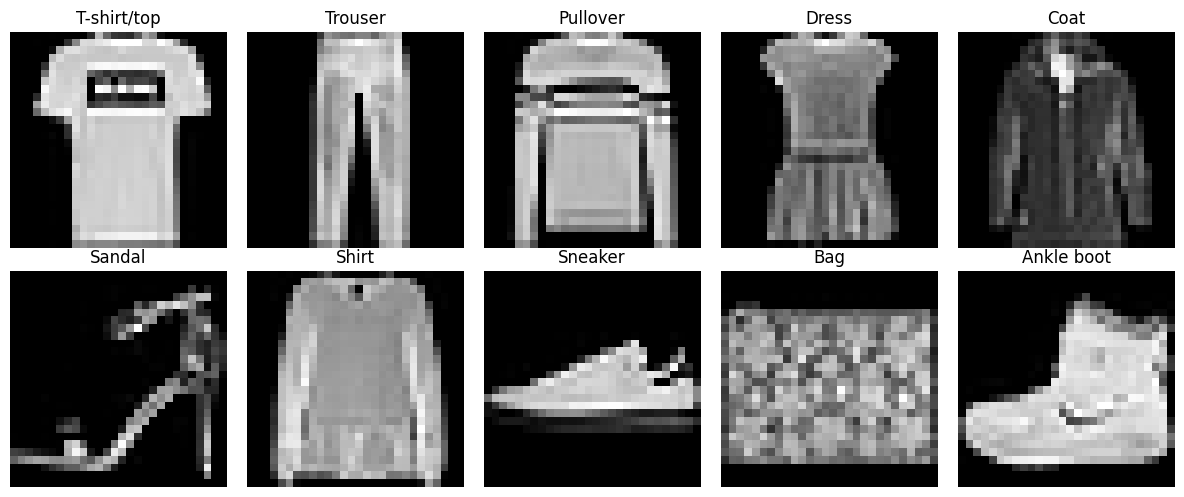

### 2.3 Class Distribution (5 Marks)

Plot a **bar chart** showing how many samples belong to each class in the training set.
- X-axis: class names
- Y-axis: count
- Title: "Training Set Class Distribution"
- Add the count number on top of each bar

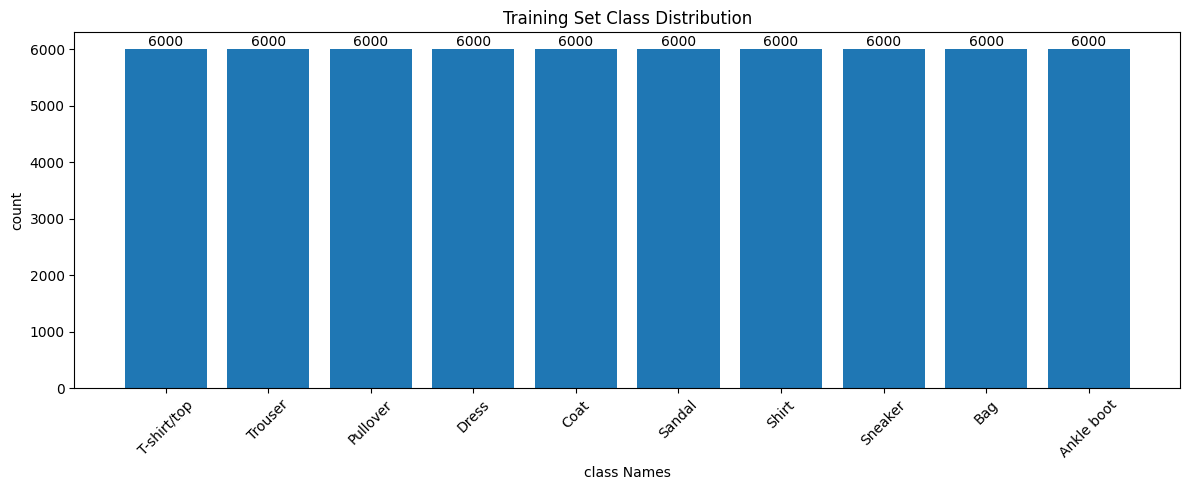

In [ ]:
# YOUR CODE HERE
classes, counts = np.unique(train_labels_all, return_counts=True)

plt.figure(figsize=(12, 5))
ba = plt.bar(class_names, counts)

plt.xlabel("class Names")
plt.ylabel("count")
plt.title("Training Set Class Distribution")

plt.xticks(rotation=45)
plt.bar_label(ba)

plt.tight_layout()
plt.show()

### 2.4 Prepare Tensors and Split (4 Marks)

Now we need to extract the data as NumPy arrays, normalize it, split it, and convert to PyTorch tensors.



**Your tasks:**
1. Normalize pixel values to **[0, 1]** by dividing by 255.0.
2. Split training data into **train (50,000)** and **validation (10,000)** using `train_test_split` with `random_state=42`.
3. Convert all sets to PyTorch tensors — images as `float32`, labels as `long`.

**Required variables:** `X_train, X_val, X_test` (tensors), `y_train, y_val, y_test` (tensors)

In [ ]:
from sklearn.model_selection import train_test_split

# YOUR CODE HERE
train_images_n = train_images_all / 255.0
test_images_n = test_images_all / 255.0

X_train_n, X_val_n, y_train_n, y_val_n = train_test_split(train_images_n,train_labels_all,test_size=10000,random_state=42,stratify=train_labels_all)

X_train = torch.tensor(X_train_n, dtype=torch.float32)
X_val = torch.tensor(X_val_n, dtype=torch.float32)
X_test = torch.tensor(test_images_n, dtype=torch.float32)

y_train = torch.tensor(y_train_n, dtype=torch.long)
y_val = torch.tensor(y_val_n, dtype=torch.long)
y_test = torch.tensor(test_labels_all, dtype=torch.long)

In [ ]:
# --- TEST CELL (DO NOT MODIFY) ---
assert X_train.shape == (50000, 28, 28), f"Expected X_train shape (50000, 28, 28), got {X_train.shape}"
assert X_val.shape == (10000, 28, 28), f"Expected X_val shape (10000, 28, 28), got {X_val.shape}"
assert X_train.dtype == torch.float32, "X_train should be float32"
assert y_train.dtype == torch.long, "y_train should be long"
assert X_train.max() <= 1.0 and X_train.min() >= 0.0, "Pixel values should be in [0, 1]"
print("✅ Q2.4 Passed!")
print(f"   Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

✅ Q2.4 Passed!
   Train: torch.Size([50000, 28, 28]), Val: torch.Size([10000, 28, 28]), Test: torch.Size([10000, 28, 28])


---

## Question 3: Build DataLoaders (10 Marks)

Create `TensorDataset` and `DataLoader` objects for the train, validation, and test sets.

- **batch_size = 64**
- **shuffle = True** for training, **False** for validation and test

**Required variables:** `train_loader`, `val_loader`, `test_loader`

In [ ]:
# YOUR CODE HERE
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
# --- TEST CELL (DO NOT MODIFY) ---
batch_X, batch_y = next(iter(train_loader))
assert batch_X.shape == (64, 28, 28), f"Batch shape should be (64, 28, 28), got {batch_X.shape}"
assert batch_y.dtype == torch.long, "Labels should be torch.long"
assert batch_X.max() <= 1.0, "Images should be normalized"
print("✅ Q3 Passed!")
print(f"   Batch images shape: {batch_X.shape}")
print(f"   Batch labels shape: {batch_y.shape}")

✅ Q3 Passed!
   Batch images shape: torch.Size([64, 28, 28])
   Batch labels shape: torch.Size([64])


---

## Question 4: Define the Model (15 Marks)

Create a class `FashionClassifier` inheriting from `nn.Module`.

Use `nn.Sequential` with this architecture:

| Layer | Description |
|-------|-------------|
| Flatten | Convert 28×28 → 784 |
| Linear | 784 → 256 |
| ReLU | Activation |
| Linear | 256 → 128 |
| ReLU | Activation |
| Linear | 128 → 64 |
| ReLU | Activation |
| Linear | 64 → 10 |

> **Note**: Do NOT apply Softmax at the output layer.

After defining the class:
1. Create an instance of `FashionClassifier`.
2. Print the model architecture.

In [ ]:
# YOUR CODE HERE
class FashionClassifier(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        return self.network(x)

model = FashionClassifier()

print(model)

FashionClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=64, bias=True)
    (6): ReLU()
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [ ]:
# --- TEST CELL (DO NOT MODIFY) ---
test_input = torch.randn(5, 28, 28)
test_output = model(test_input)
assert test_output.shape == (5, 10), f"Output shape should be (5, 10), got {test_output.shape}"
total_params = sum(p.numel() for p in model.parameters())
assert total_params > 0, "Model should have trainable parameters"
print("✅ Q4 Passed!")
print(f"   Total parameters: {total_params}")
print(model)

✅ Q4 Passed!
   Total parameters: 242762
FashionClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=64, bias=True)
    (6): ReLU()
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)


---

## Question 5: Train the Model (25 Marks)

### 5.1 Set Up Training (5 Marks)
- Loss function: `nn.CrossEntropyLoss`
- Optimizer: `optim.SGD` with `lr=0.01`
- Number of epochs: **15**

In [ ]:
# YOUR CODE HERE
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)
epochs = 15

### 5.2 Training Loop (15 Marks)

Write a complete training loop for **15 epochs**.

For each epoch:
- Train on `train_loader` and compute training loss
- Evaluate on `val_loader` (with `torch.no_grad()`) and compute validation loss
- Print: `Epoch {epoch+1}/{epochs} | Train Loss: {:.4f} | Val Loss: {:.4f} `

Store: `train_losses`, `val_losses`, (lists, one value per epoch).

In [ ]:
# YOUR CODE HERE
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []


for epoch in range(epochs):

  running_loss = 0.0
  running_tr_acc = 0.0

  for images,labels in train_loader :
    optimizer.zero_grad()

    outputs = model(images)

    loss = criterion(outputs,labels )

    loss.backward()

    optimizer.step()

    running_loss+= loss.item()

    predictions = torch.argmax(outputs, dim=1)
    running_tr_acc += (predictions == labels).float().mean().item()

  epoch_train_loss = running_loss / len(train_loader)
  train_losses.append(epoch_train_loss)
  train_accuracies.append(running_tr_acc / len(train_loader))

  val_loss = 0.0
  running_vl_acc = 0.0

  with torch.no_grad():
    for images,labels in val_loader :
      outputs = model(images)
      loss = criterion(outputs,labels)
      val_loss+= loss.item()

      predictions = torch.argmax(outputs, dim=1)
      running_vl_acc += (predictions == labels).float().mean().item()

  epoch_val_loss = val_loss / len(val_loader)
  val_losses.append(epoch_val_loss)
  val_accuracies.append(running_vl_acc / len(val_loader))


  print(f'Epoch {epoch+1}/ {epochs} | Train Loss : {running_loss:.4f} | Validation Loss: {val_loss:.4f}'
  )

Epoch 1/ 15 | Train Loss : 1519.4730 | Validation Loss: 183.1777
Epoch 2/ 15 | Train Loss : 708.1057 | Validation Loss: 122.4000
Epoch 3/ 15 | Train Loss : 562.3247 | Validation Loss: 104.5093
Epoch 4/ 15 | Train Loss : 497.6557 | Validation Loss: 104.6041
Epoch 5/ 15 | Train Loss : 455.0719 | Validation Loss: 85.2674
Epoch 6/ 15 | Train Loss : 425.2452 | Validation Loss: 81.9748
Epoch 7/ 15 | Train Loss : 402.7020 | Validation Loss: 88.8691
Epoch 8/ 15 | Train Loss : 385.3247 | Validation Loss: 75.4337
Epoch 9/ 15 | Train Loss : 370.6439 | Validation Loss: 77.8560
Epoch 10/ 15 | Train Loss : 358.8435 | Validation Loss: 78.6273
Epoch 11/ 15 | Train Loss : 347.4922 | Validation Loss: 76.5635
Epoch 12/ 15 | Train Loss : 337.8087 | Validation Loss: 66.8708
Epoch 13/ 15 | Train Loss : 329.9768 | Validation Loss: 70.7066
Epoch 14/ 15 | Train Loss : 322.2821 | Validation Loss: 63.0358
Epoch 15/ 15 | Train Loss : 315.3570 | Validation Loss: 64.5453


In [ ]:
# --- TEST CELL (DO NOT MODIFY) ---
assert len(train_losses) == 15, f"Expected 15 epochs, got {len(train_losses)}"
assert len(val_losses) == 15
assert train_losses[-1] < train_losses[0], "Training loss should decrease"
print("✅ Q5.2 Passed!")
print(f"   Final Train Acc: {train_accuracies[-1]:.2f}%, Final Val Acc: {val_accuracies[-1]:.2f}%")

✅ Q5.2 Passed!
   Final Train Acc: 0.86%, Final Val Acc: 0.85%


### 5.3 Test Evaluation (5 Marks)

Evaluate the model on the **test set**. Print the test_accuracy (required_variable)

Also, collect all test predictions and true labels into lists called `all_preds` and `all_labels` (we'll use them for analysis later).

Print: `Test Accuracy: {:.2f}%`

In [ ]:
# YOUR CODE HERE
all_preds = []
all_labels = []

corr_count = 0
to_sample = 0

my_test_accuracy = 0.0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        all_preds.extend(predictions.tolist())
        all_labels.extend(labels.tolist())

        my_test_accuracy += (predictions == labels).float().mean().item()

        # corr_count += (predictions == labels).sum().item()
        # to_sample += labels.size(0)

# correct_count = sum(p == l for p, l in zip(all_preds, all_labels))
# test_accuracy = (correct_count / len(all_labels)) * 100

test_accuracy = (my_test_accuracy / len(test_loader)) * 100

# test_accuracy = (corr_count / to_sample) * 100

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 83.76%


In [ ]:
# --- TEST CELL (DO NOT MODIFY) ---
assert test_accuracy > 40.0, f"Test accuracy should be > 40%, got {test_accuracy:.2f}%"
assert len(all_preds) == len(X_test), "Predictions should cover all test samples"
print(f"✅ Q5.3 Passed! Test Accuracy: {test_accuracy:.2f}%")

✅ Q5.3 Passed! Test Accuracy: 83.76%


---

## Question 6: Visualize & Analyze Results (25 Marks)

### 6.1 Plot Training Loss vs Validation Loss (5 Marks)

Plot **Training Loss** and **Validation Loss** on the same figure across epochs.
- Include a legend, title ("Loss Curve"), and axis labels.

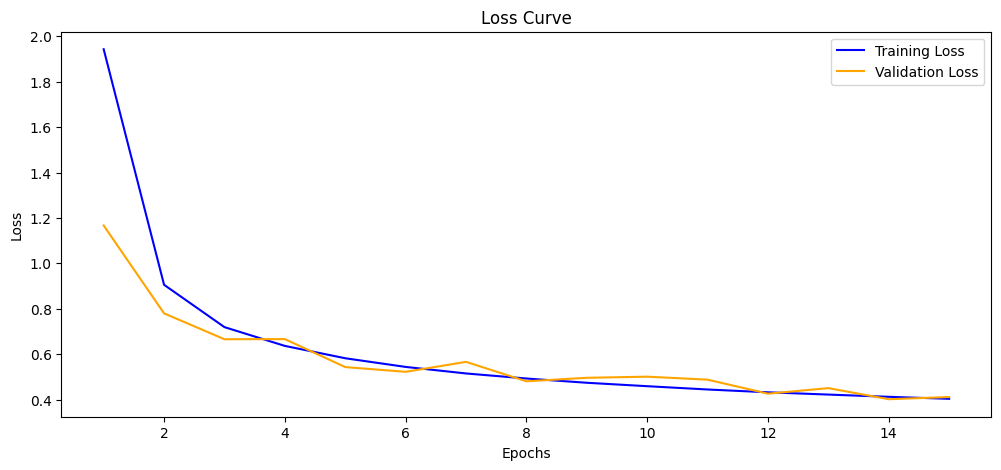

In [ ]:
# YOUR CODE HERE
plt.figure(figsize=(12, 5))
plt.plot(range(1, epochs+1), train_losses, label='Training Loss', color='blue')
plt.plot(range(1, epochs+1), val_losses, label='Validation Loss', color='orange')

plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

### 6.2 Plot Training Accuracy vs Validation Accuracy (5 Marks)

Plot **Training Accuracy** and **Validation Accuracy** on the same figure across epochs.
- Include a legend, title ("Accuracy Curve"), and axis labels.

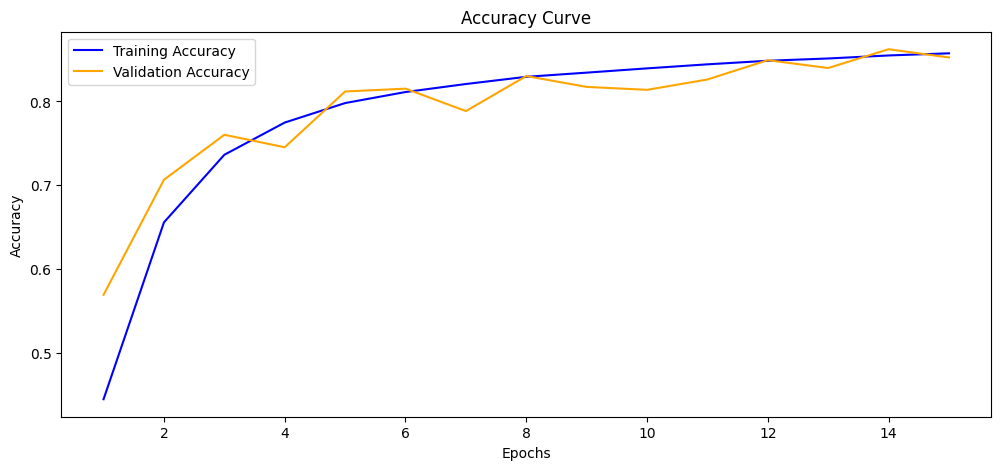

In [ ]:
# YOUR CODE HERE
plt.figure(figsize=(12, 5))
plt.plot(range(1, epochs+1), train_accuracies, label='Training Accuracy', color='blue')
plt.plot(range(1, epochs+1), val_accuracies, label='Validation Accuracy', color='orange')

plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

### 6.3 Confusion Matrix (5 Marks)

Using `sklearn.metrics`:
1. Compute the confusion matrix on test predictions.
2. Display it as a heatmap using `ConfusionMatrixDisplay` with `class_names` as labels.
3. Title: "StyleAI Fashion Classifier — Test Confusion Matrix"

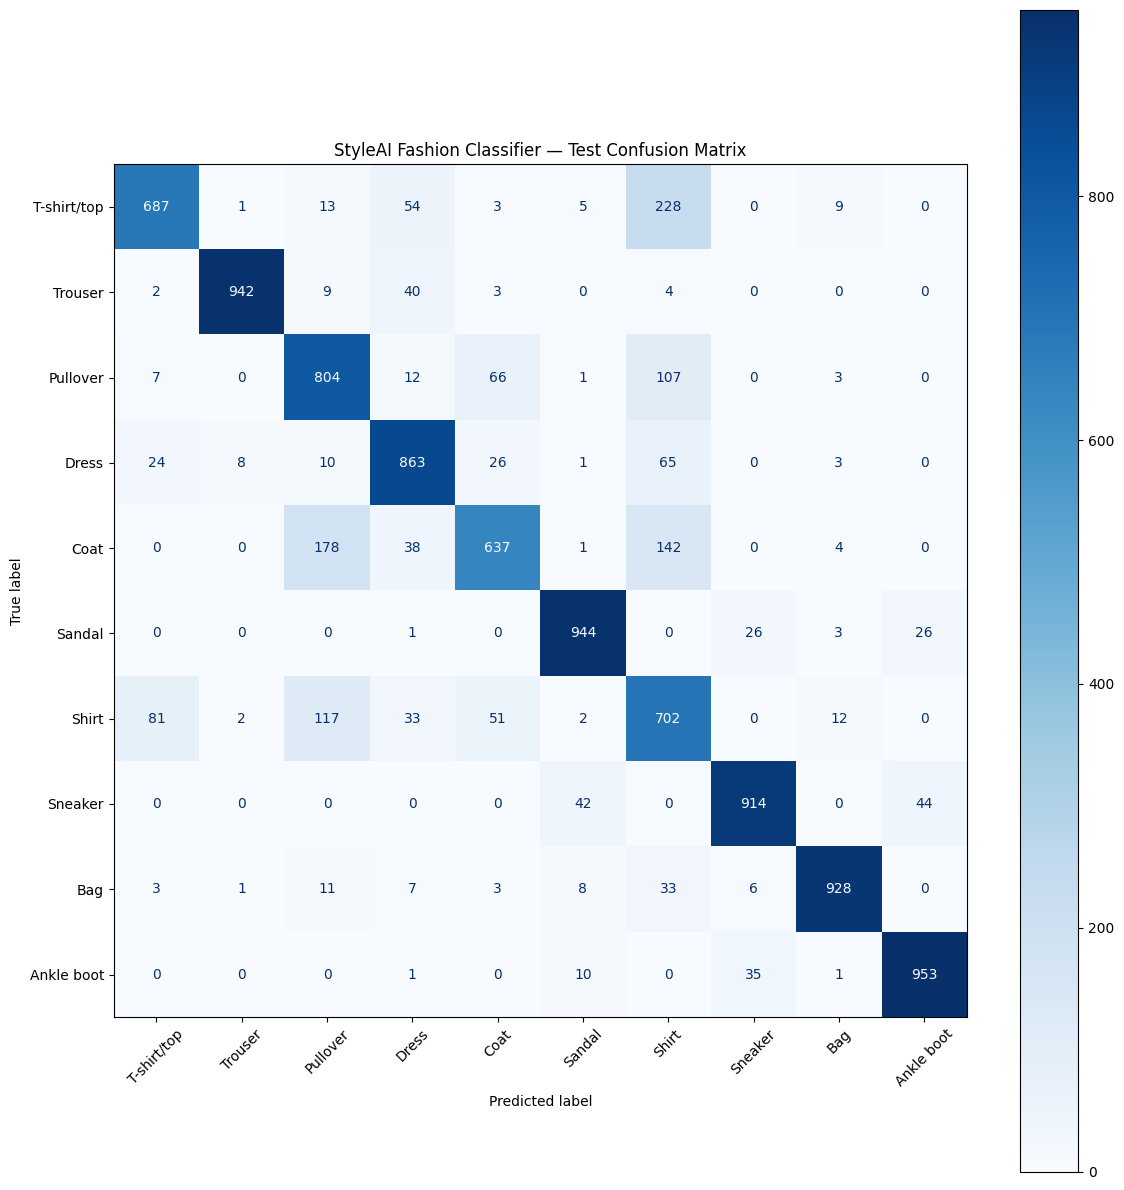

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# YOUR CODE HERE
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(12, 12))

displ = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

displ.plot(ax=ax, cmap="Blues", xticks_rotation=45)

plt.title("StyleAI Fashion Classifier — Test Confusion Matrix")

plt.tight_layout()
plt.show()

### 6.4 Classification Report (5 Marks)

Print the `classification_report` from sklearn using `target_names=class_names`.

In [ ]:
from sklearn.metrics import classification_report

# YOUR CODE HERE
cl_report = classification_report(all_labels, all_preds, target_names = class_names)

print(cl_report)

              precision    recall  f1-score   support

 T-shirt/top       0.85      0.69      0.76      1000
     Trouser       0.99      0.94      0.96      1000
    Pullover       0.70      0.80      0.75      1000
       Dress       0.82      0.86      0.84      1000
        Coat       0.81      0.64      0.71      1000
      Sandal       0.93      0.94      0.94      1000
       Shirt       0.55      0.70      0.62      1000
     Sneaker       0.93      0.91      0.92      1000
         Bag       0.96      0.93      0.95      1000
  Ankle boot       0.93      0.95      0.94      1000

    accuracy                           0.84     10000
   macro avg       0.85      0.84      0.84     10000
weighted avg       0.85      0.84      0.84     10000



### 6.5 Written Analysis (5 Marks)

In the markdown cell below, answer:
1. Which two classes are **most often confused** with each other? Look at the confusion matrix and explain **why** (think about visual similarity).
2. Is the model **overfitting or underfitting**? How can you tell from the learning curves?

*Double-click here to write your analysis*

**Your Analysis:** Shirt precision 0.55 and recall 0.70 and Pullover precision 0.70 and recall 0.80. I think this two classes confused with each other.In fashion-mnist data set image are low resolution and grayscale.At this resolution shirt and pullover near identical.

The model is well-fitted model. Because training accuracy increasing and validation accuracy increasing. The model is successfully converged
